# IPL Trend Analysis

## Trend: Opening partnership contribution per inning to success of match 


Stage 1: Transforming Dataset

In [1]:
import pandas as pd

df = pd.read_csv("deliveries.csv")

df = df.sort_values(
    by=["match_id", "inning", "over", "ball"]
).reset_index(drop=True)

df.head(10)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
5,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,6,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
6,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,7,BB McCullum,P Kumar,SC Ganguly,0,1,1,legbyes,0,NaN,NaN,NaN
7,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,1,1,BB McCullum,Z Khan,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
8,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,1,2,BB McCullum,Z Khan,SC Ganguly,4,0,4,NaN,0,NaN,NaN,NaN
9,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,1,3,BB McCullum,Z Khan,SC Ganguly,4,0,4,NaN,0,NaN,NaN,NaN


Stage 2: Get Wicket Information

In [2]:
wickets = df[df["is_wicket"] == 1]
wickets.head()

first_wicket = (
    wickets
    .groupby(["match_id", "inning", "batting_team"])
    .first()
    .reset_index()
)

first_wicket = first_wicket[
    ["match_id", "inning", "batting_team", "over", "ball"]
]

first_wicket.head(10)

,match_id,inning,batting_team,over,ball
0,335982,1,Kolkata Knight Riders,5,2
1,335982,2,Royal Challengers Bangalore,1,1
2,335983,1,Chennai Super Kings,2,5
3,335983,2,Kings XI Punjab,5,6
4,335984,1,Rajasthan Royals,2,3
5,335984,2,Delhi Daredevils,1,4
6,335985,1,Mumbai Indians,1,5
7,335985,2,Royal Challengers Bangalore,4,7
8,335986,1,Deccan Chargers,3,2
9,335986,2,Kolkata Knight Riders,1,2


Stage 3: Get Run and Ball Info Till First Wicket

In [3]:
df_with_wicket = df.merge(
    first_wicket,
    on=["match_id", "inning", "batting_team"],
    suffixes=("", "_wicket"), # adds suffix to distinguish between columns from df and first_wicket
    how="inner" # only keep rows that have a corresponding first wicket (i.e., only consider innings where at least one wicket fell
)

df_with_wicket.head(10)

runs_before_wicket = df_with_wicket[
    (df_with_wicket["over"] < df_with_wicket["over_wicket"]) |
    (
        (df_with_wicket["over"] == df_with_wicket["over_wicket"]) &
        (df_with_wicket["ball"] < df_with_wicket["ball_wicket"])
    )
]
runs_before_wicket.reset_index(drop=True, inplace=True)
runs_before_wicket.head(10)

runs_summary = (
    runs_before_wicket
    .groupby(["match_id", "inning", "batting_team"], as_index=False)
    .agg(
        runs_before_first_wicket=("total_runs", "sum"),
        balls_before_first_wicket=("ball", "count")
    )
)

runs_summary.head(10)

,match_id,inning,batting_team,runs_before_first_wicket,balls_before_first_wicket
0,335982,1,Kolkata Knight Riders,61,33
1,335982,2,Royal Challengers Bangalore,4,7
2,335983,1,Chennai Super Kings,26,17
3,335983,2,Kings XI Punjab,56,35
4,335984,1,Rajasthan Royals,17,15
5,335984,2,Delhi Daredevils,20,9
6,335985,1,Mumbai Indians,9,10
7,335985,2,Royal Challengers Bangalore,37,30
8,335986,1,Deccan Chargers,21,22
9,335986,2,Kolkata Knight Riders,6,7


Stage 4: Adding Ranges for Trend Analysis

In [4]:
bins = [-1, 10, 20, 30, 40, 60, 200]
labels = ["0–10", "11–20", "21–30", "31–40", "41–60", "60+"]

runs_summary["run_bucket"] = pd.cut(
    runs_summary["runs_before_first_wicket"],
    bins=bins,
    labels=labels,
    right=True
)

runs_summary.head(10)

runs_summary = runs_summary[
    runs_summary["inning"].isin([1, 2])
] #super innings detected in the dataset

bucket_distribution = (
    runs_summary
    .groupby("run_bucket", observed=True)
    .size() 
    .reset_index(name="innings_count")
)

bucket_distribution

innings_trend = (
    runs_summary
    .groupby(["inning", "run_bucket"], observed=True)
    .size()
    .reset_index(name="innings_count")
)

innings_trend.head(20) 



,inning,run_bucket,innings_count
0,1,0–10,288
1,1,11–20,200
2,1,21–30,139
3,1,31–40,103
4,1,41–60,149
5,1,60+,183
6,2,0–10,316
7,2,11–20,179
8,2,21–30,133
9,2,31–40,95


Stage 5: Plotting using Matplotlib and Seaborn

C:\Users\tseb3003\AppData\Local\Temp\ipykernel_8480\3119421100.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax =sns.barplot(


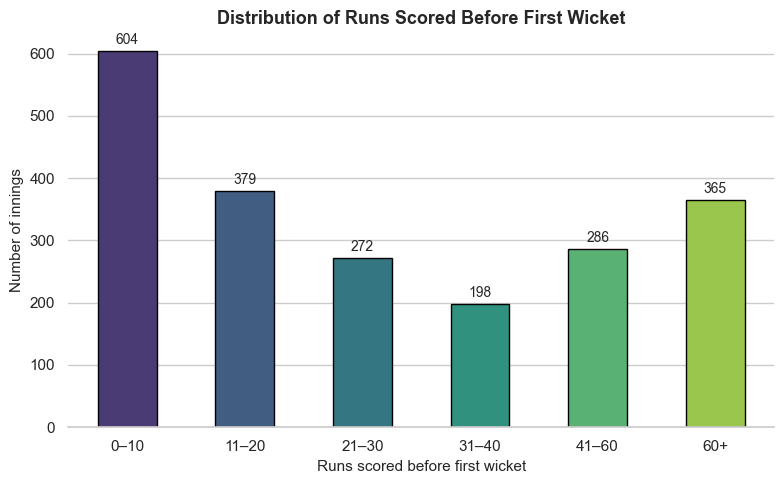

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))

ax =sns.barplot(
    data=bucket_distribution,
    x="run_bucket",
    y="innings_count",
    palette="viridis",   # nice gradient colors
    width=0.5,            # skinnier bars
    edgecolor="black"     # crisp bar edges
)

plt.xlabel("Runs scored before first wicket", fontsize=11)
plt.ylabel("Number of innings", fontsize=11)
plt.title(
    "Distribution of Runs Scored Before First Wicket",
    fontsize=13,
    weight="bold"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",           # integer formatting
        padding=3,          # space above bars
        fontsize=10
    )

sns.despine(left=True)  # remove left border for cleaner look
plt.tight_layout()
plt.show()


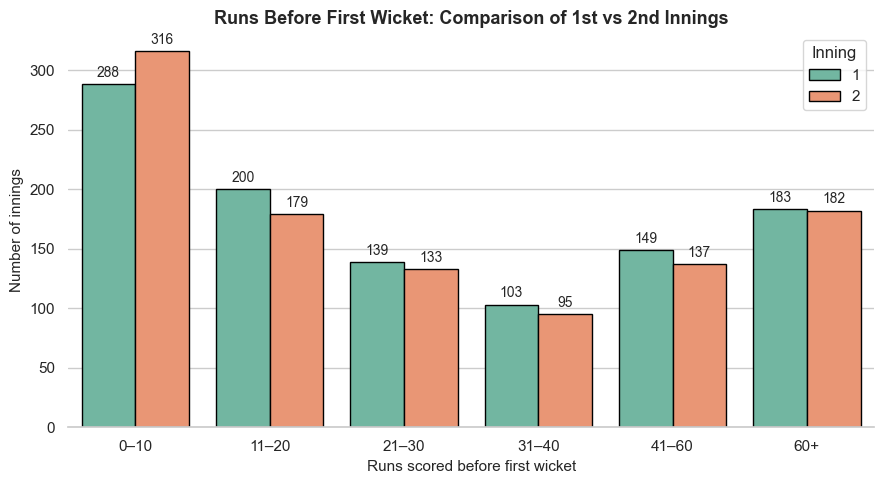

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

bucket_order = ["0–10", "11–20", "21–30", "31–40", "41–60", "60+"]
innings_trend["run_bucket"] = pd.Categorical(
    innings_trend["run_bucket"],
    categories=bucket_order,
    ordered=True
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=innings_trend,
    x="run_bucket",
    y="innings_count",
    hue="inning",
    palette="Set2",     # clear distinction for innings
    width=0.8,         # skinnier bars
    edgecolor="black"
)

plt.xlabel("Runs scored before first wicket", fontsize=11)
plt.ylabel("Number of innings", fontsize=11)
plt.title(
    "Runs Before First Wicket: Comparison of 1st vs 2nd Innings",
    fontsize=13,
    weight="bold"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3,
        fontsize=10
    )

plt.legend(title="Inning")
sns.despine(left=True)
plt.tight_layout()
plt.show()

Stage 6: Win Loss Comparison 

In [7]:
matches = pd.read_csv("matches.csv")
matches = matches[["id", "winner"]]
matches.head(10)

,id,winner
0,335982,Kolkata Knight Riders
1,335983,Chennai Super Kings
2,335984,Delhi Daredevils
3,335985,Royal Challengers Bangalore
4,335986,Kolkata Knight Riders
5,335987,Rajasthan Royals
6,335988,Delhi Daredevils
7,335989,Chennai Super Kings
8,335990,Rajasthan Royals
9,335991,Kings XI Punjab


In [8]:
runs_summary = runs_summary.merge(
    matches,
    left_on="match_id",
    right_on="id",
    how="left"
)

runs_summary.head(10)

,match_id,inning,batting_team,runs_before_first_wicket,balls_before_first_wicket,run_bucket,id,winner
0,335982,1,Kolkata Knight Riders,61,33,60+,335982,Kolkata Knight Riders
1,335982,2,Royal Challengers Bangalore,4,7,0–10,335982,Kolkata Knight Riders
2,335983,1,Chennai Super Kings,26,17,21–30,335983,Chennai Super Kings
3,335983,2,Kings XI Punjab,56,35,41–60,335983,Chennai Super Kings
4,335984,1,Rajasthan Royals,17,15,11–20,335984,Delhi Daredevils
5,335984,2,Delhi Daredevils,20,9,11–20,335984,Delhi Daredevils
6,335985,1,Mumbai Indians,9,10,0–10,335985,Royal Challengers Bangalore
7,335985,2,Royal Challengers Bangalore,37,30,31–40,335985,Royal Challengers Bangalore
8,335986,1,Deccan Chargers,21,22,21–30,335986,Kolkata Knight Riders
9,335986,2,Kolkata Knight Riders,6,7,0–10,335986,Kolkata Knight Riders


In [9]:
runs_summary["win"] = (
    runs_summary["batting_team"] == runs_summary["winner"]
).astype(int)

runs_summary[["match_id", "batting_team", "winner", "win"]].head(10)

,match_id,batting_team,winner,win
0,335982,Kolkata Knight Riders,Kolkata Knight Riders,1
1,335982,Royal Challengers Bangalore,Kolkata Knight Riders,0
2,335983,Chennai Super Kings,Chennai Super Kings,1
3,335983,Kings XI Punjab,Chennai Super Kings,0
4,335984,Rajasthan Royals,Delhi Daredevils,0
5,335984,Delhi Daredevils,Delhi Daredevils,1
6,335985,Mumbai Indians,Royal Challengers Bangalore,0
7,335985,Royal Challengers Bangalore,Royal Challengers Bangalore,1
8,335986,Deccan Chargers,Kolkata Knight Riders,0
9,335986,Kolkata Knight Riders,Kolkata Knight Riders,1


In [21]:
win_trend = (
    runs_summary
    .groupby("run_bucket", observed=True)
    .agg(
        total_innings=("win", "count"),
        wins=("win", "sum"),
        win_rate=("win", "mean")
    )
    .reset_index()
)

win_trend["win_rate"] = win_trend["win_rate"] * 100
win_trend

,run_bucket,total_innings,wins,win_rate
0,0–10,604,240,39.735099
1,11–20,379,165,43.535620
2,21–30,272,126,46.323529
3,31–40,198,91,45.959596
4,41–60,286,174,60.839161
5,60+,365,252,69.041096


Stage 7: Plotting using Matplotlib and Seaborn

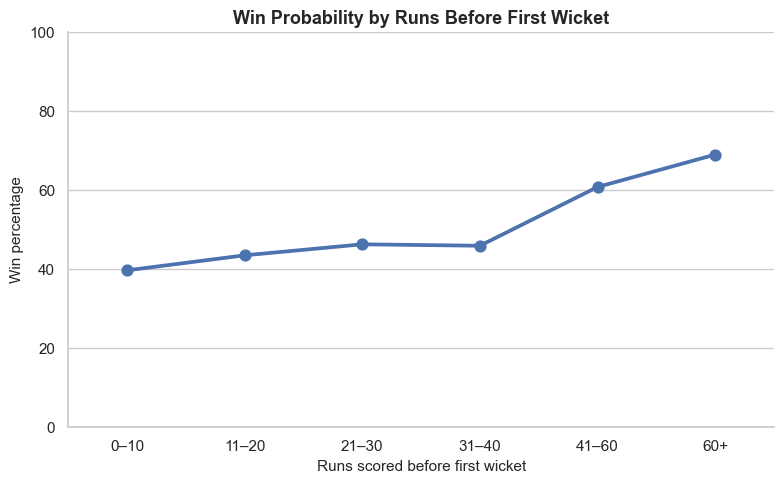

In [28]:
plt.figure(figsize=(8, 5))

sns.pointplot(
    data=win_trend,
    x="run_bucket",
    y="win_rate",
    color="#4C72B0"
)

plt.xlabel("Runs scored before first wicket", fontsize=11)
plt.ylabel("Win percentage", fontsize=11)
plt.title(
    "Win Probability by Runs Before First Wicket",
    fontsize=13,
    weight="bold"
)

plt.ylim(0, 100)
sns.despine()
plt.tight_layout()
plt.show()



Note: Innings with values other than 1 and 2 were excluded because they do not represent standard batting innings in limited‑overs cricket and would otherwise introduce noise into the trend analysis.